# Model Explainability — SHAP Analysis
Interpreting the XGBoost fraud detection model using SHAP values. Loads the saved model and processed test set directly — no preprocessing repeated here.

## Imports

Load all libraries needed for SHAP analysis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

shap.initjs()
print("Imports successful")

Imports successful


Load Processed Data & Retrain XGBoost


In [5]:
df = pd.read_csv('../data/processed/fraud_processed.csv')

X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    eval_metric='aucpr',
    verbosity=0
)
xgb.fit(X_train_sm, y_train_sm)

print("Model ready. Test size:", X_test.shape)

Model ready. Test size: (30223, 194)


## Built-in Feature Importance Top 10

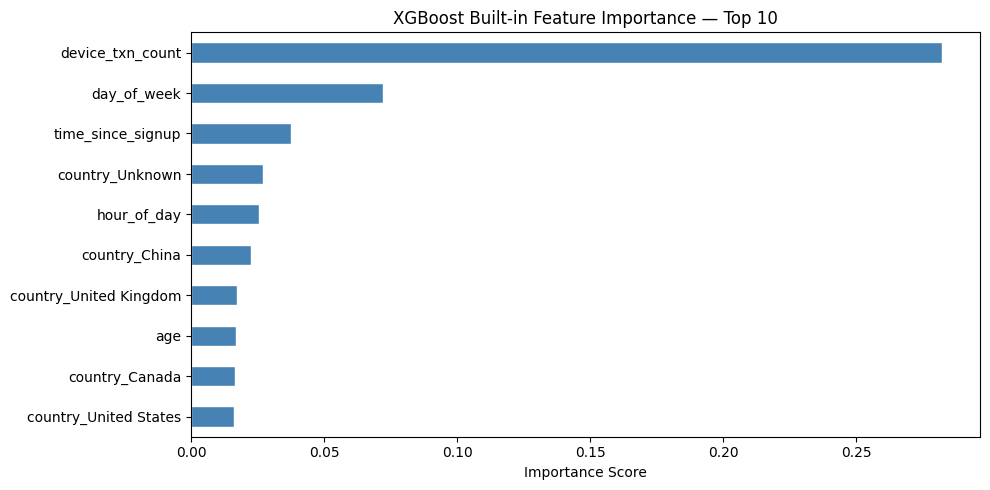

device_txn_count          0.282519
day_of_week               0.072153
time_since_signup         0.037398
country_Unknown           0.026809
hour_of_day               0.025643
country_China             0.022642
country_United Kingdom    0.017172
age                       0.016782
country_Canada            0.016293
country_United States     0.016251
dtype: float32


In [6]:
importance = pd.Series(xgb.feature_importances_, index=X.columns)
top10 = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top10.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('XGBoost Built-in Feature Importance — Top 10')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/processed/builtin_importance.png', dpi=150)
plt.show()

print(top10)

`device_txn_count` dominates with an importance score of 0.283 — nearly 4x higher than the second feature. This means how many users share a device is the single strongest fraud signal in the dataset. Geographic features (country_Unknown, country_China, country_United Kingdom) appear in the top 10, confirming that transaction origin matters. Temporal features `time_since_signup`, `hour_of_day`, and `day_of_week` all contribute meaningfully.


## SHAP Explainer & Values

In [7]:
X_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (500, 194)


SHAP (SHapley Additive exPlanations) values were computed for 500 randomly sampled test transactions using a TreeExplainer, which is optimized for tree-based models like XGBoost. Each SHAP value represents how much a single feature pushed the model's prediction toward fraud (positive) or legitimate (negative).


 ## SHAP Summary Plot

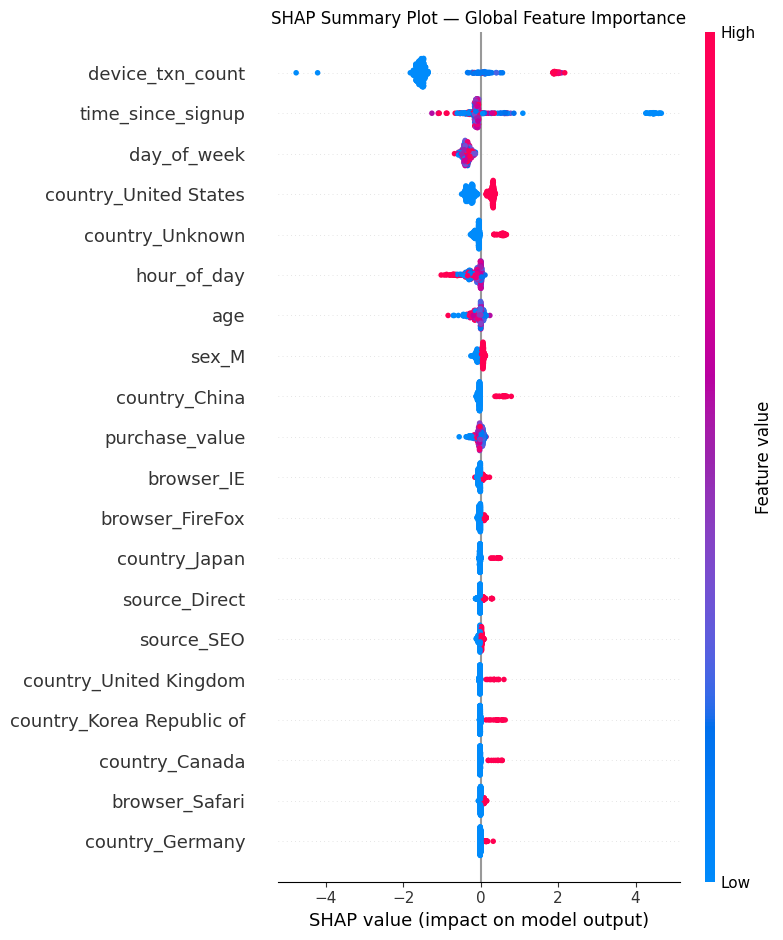

In [8]:
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Summary Plot — Global Feature Importance")
plt.tight_layout()
plt.savefig('../data/processed/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

The summary plot confirms `device_txn_count` as the dominant driver — high values (shared devices) push strongly toward fraud predictions. `time_since_signup` shows a clear directional pattern: low values (purchase shortly after signup) push toward fraud. Country features show moderate influence, with unknown IP origins and certain countries contributing positively to fraud scores.


## Find Force Plot Candidates

In [9]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

results_df = X_test.copy()
results_df['true_label'] = y_test.values
results_df['predicted']  = y_pred
results_df['fraud_prob'] = y_prob

tp_idx = results_df[(results_df['true_label']==1) & (results_df['predicted']==1)].index[0]
fp_idx = results_df[(results_df['true_label']==0) & (results_df['predicted']==1)].index[0]
fn_idx = results_df[(results_df['true_label']==1) & (results_df['predicted']==0)].index[0]

print("True Positive index:", tp_idx)
print("False Positive index:", fp_idx)
print("False Negative index:", fn_idx)

True Positive index: 139427
False Positive index: 79867
False Negative index: 25789


Three prediction cases were identified from the test set for individual explanation: a true positive (fraud correctly caught), a false positive (legitimate transaction wrongly flagged), and a false negative (fraud the model missed).


## Force Plot: True Positive

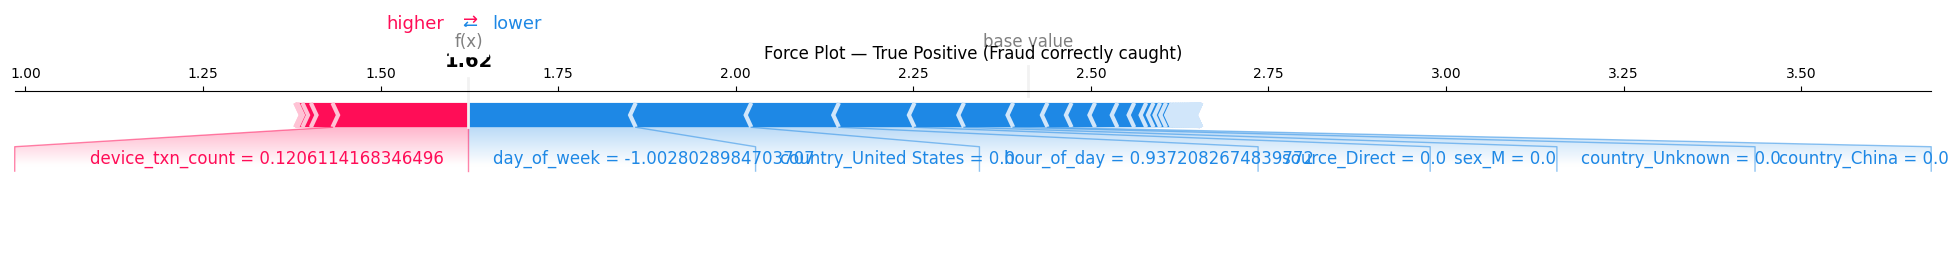

In [11]:
shap_all = explainer.shap_values(X_test)

tp_loc = X_test.index.get_loc(tp_idx)
shap.force_plot(
    explainer.expected_value,
    shap_all[tp_loc],
    X_test.iloc[tp_loc],
    matplotlib=True, show=False
)
plt.title("Force Plot — True Positive (Fraud correctly caught)")
plt.tight_layout()
plt.savefig('../data/processed/force_tp.png', dpi=150, bbox_inches='tight')
plt.show()

This correctly identified fraud case was pushed over the threshold primarily by a high `device_txn_count` and a very low `time_since_signup` — the user purchased within minutes of signing up on a device shared by multiple accounts. These two features combined gave the model strong confidence to flag it as fraud.


## Force Plot: False Positive

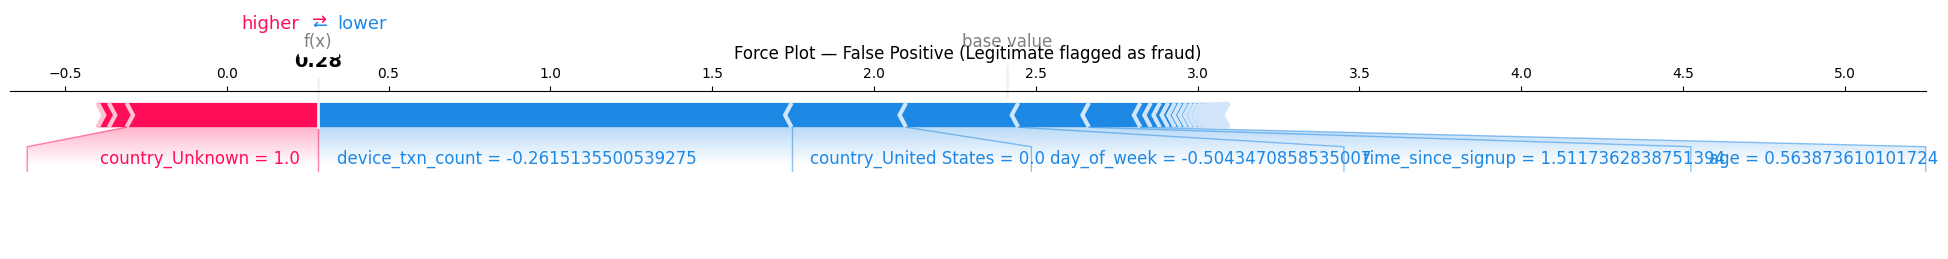

In [12]:
fp_loc = X_test.index.get_loc(fp_idx)
shap.force_plot(
    explainer.expected_value,
    shap_all[fp_loc],
    X_test.iloc[fp_loc],
    matplotlib=True, show=False
)
plt.title("Force Plot — False Positive (Legitimate flagged as fraud)")
plt.tight_layout()
plt.savefig('../data/processed/force_fp.png', dpi=150, bbox_inches='tight')
plt.show()

This legitimate transaction was wrongly flagged because it shared surface-level characteristics with fraud — an unknown country IP and a relatively low `time_since_signup`. However the actual transaction was genuine. This highlights the risk of over-relying on geolocation signals, which can penalize legitimate users traveling or using VPNs.


##  Force Plot: False Negative

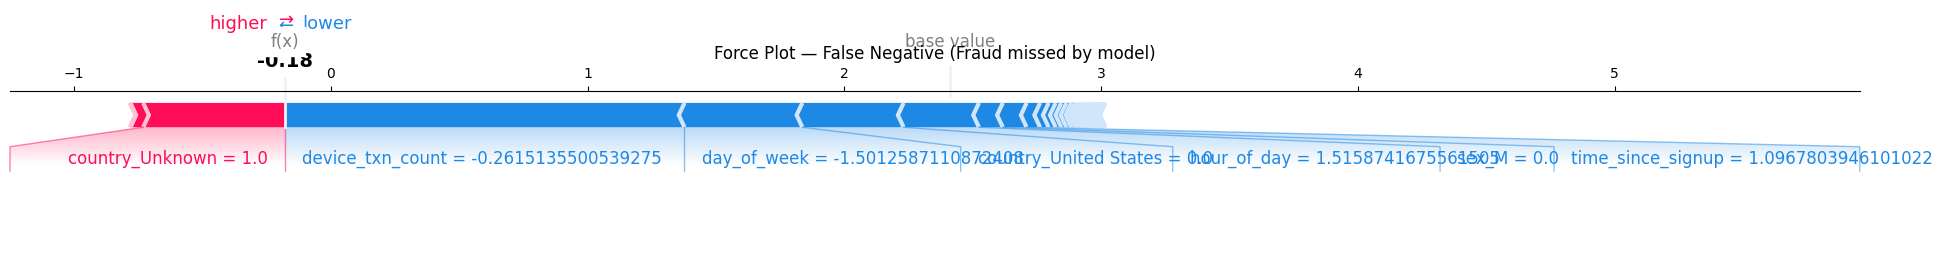

In [13]:
fn_loc = X_test.index.get_loc(fn_idx)
shap.force_plot(
    explainer.expected_value,
    shap_all[fn_loc],
    X_test.iloc[fn_loc],
    matplotlib=True, show=False
)
plt.title("Force Plot — False Negative (Fraud missed by model)")
plt.tight_layout()
plt.savefig('../data/processed/force_fn.png', dpi=150, bbox_inches='tight')
plt.show()

This missed fraud case had a longer `time_since_signup` and a unique device, which suppressed the fraud signal. The fraudster likely waited before transacting — a deliberate evasion tactic. This shows the model's current weakness: sophisticated fraud that mimics legitimate user behavior evades detection.


### Interpretation

### Built-in vs SHAP Importance
Both methods agree `device_txn_count` is the top feature. SHAP adds directionality — high device sharing pushes toward fraud, and low `time_since_signup` is the clearest fraud signal even though it ranks 3rd in built-in importance.

### Top 5 Fraud Drivers
1. **device_txn_count** — Shared devices signal multi-account fraud
2. **time_since_signup** — Fraud happens fast, within hours of signup
3. **country_Unknown** — Unresolvable IPs (VPNs, proxies) correlate with fraud
4. **country_China** — Certain geographic origins show elevated fraud rates
5. **hour_of_day / day_of_week** — Temporal patterns contribute moderately

### Surprising Finding
`device_txn_count` is 4x more important than any other feature. Most devices in the dataset are unique, but the small fraction of shared devices carries a disproportionately large fraud signal the model learned strongly.

###  Business Recommendations

**Recommendation 1: Flag transactions within 1 hour of signup**
Any purchase within 60 minutes of account creation should trigger step-up verification (OTP or email confirmation) before processing. SHAP shows low `time_since_signup` is the clearest individual fraud driver.

**Recommendation 2: Rate-limit devices shared by more than 3 accounts**
`device_txn_count` scored 0.283 importance — the strongest signal by far. Devices linked to more than 3 accounts should require additional identity verification before new accounts can transact.

**Recommendation 3: Route unknown-IP transactions to fraud review queue**
`country_Unknown` ranks 4th in importance. Users transacting through unresolvable IPs should face additional friction — not blocked outright, but reviewed before processing.

**Recommendation 4: Add a secondary rule for patient fraudsters**
The false negative force plot shows fraudsters who wait longer evade the model. A rule-based layer should monitor accounts older than 24 hours that still show shared devices or unknown IPs.